In [31]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error,r2_score
import pandas as pd
from sklearn.model_selection import train_test_split

In [15]:
insurance_data = pd.read_csv("12. insurance.csv")


X = insurance_data.drop(columns=["charges"])
y = insurance_data["charges"]

X = pd.get_dummies(X, columns=["region"], drop_first=True,dtype=int)

X["sex"] = X["sex"].map({"female": 1, "male": 0})
X["smoker"] = X["smoker"].map({"yes": 1, "no": 0})

X["age_smoker"]=X["age"] * X["smoker"]
X["bmi_smoker"]=X["bmi"] * X["smoker"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


MSE for aplhas=0.001 : 20922599.871035974
MSE for aplhas=1 : 20914832.635089148
MSE for aplhas=2 : 20908106.779954527
MSE for aplhas=3 : 20901927.931570232
MSE for aplhas=4 : 20896130.81113566
MSE for aplhas=5 : 20890881.000633508
MSE for aplhas=12 : 20869462.906981695
MSE for aplhas=30 : 20937537.133939765
MSE for aplhas=40 : 21046489.293890767
MSE for aplhas=70.1 : 21636335.987673946


<Axes: >

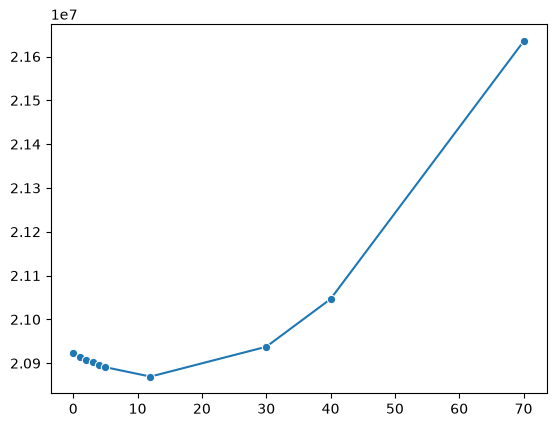

In [25]:
import seaborn as sns

alphas = [0.001,1,2,3,4,5,12,30,40,70.100]
mses=[]
for a in alphas:
    lasso_model =Lasso(alpha=a)
    lasso_model.fit(X_train,y_train)
    
    
    y_pred = lasso_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f"MSE for aplhas={a} :",mse)
    mses.append(mse)
    
sns.lineplot(x=alphas,y=mses,marker="o")    

In [33]:
from sklearn.linear_model import LassoCV
a = [0.001,1,2,3,4,5,12,30,40,70.100]

lasso_cv_model = LassoCV(
    alphas=a,
    cv=5,
    max_iter=1000,
    random_state=42
    
)

lasso_cv_model.fit(X_train,y_train)
print("beat alpha :",lasso_cv_model.alpha_)

y_pred=lasso_cv_model.predict(X_test)
mse = mean_squared_error(y_test,y_pred)

r2=r2_score(y_test,y_pred)
print("MSE : ",mse)
print("s2", r2)

beat alpha : 0.001
MSE :  20922599.871035974
s2 0.8652317499151698
